# Fungsi Preprocessing pada data raw

## 1. Mengimpor Library dan module yang dibutuhkan

WAJIB ADA KARENA INI NOTEBOOK

In [3]:
# LIBRARY
import sys
sys.path.append('..')
# Menambahkan path ke folder parent (satu level di atas)
# Tujuannya agar bisa import module dari folder src/
# (karena notebook ada di folder notebooks/)

# LIBRARY DAN MODULE DARI FILE LAIN
import pandas as pd
from sklearn.model_selection import train_test_split
from src import bersihkan_teks_total,bersihkan_teks_minimal,encode_label_series
from src import simpan_objek  

## 2. Logika Code

### 2.1 Load dataset

In [4]:
import pandas as pd

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/raw/dataset_gabungan.csv")


# ============================================================
# 🔥 TAMBAHAN DATA FAKTA (BANYAK & VARIATIF)
# ============================================================

data_tambahan = [

    # =========================
    # KESEHATAN (REALISTIS)
    # =========================
    ("WHO mengimbau masyarakat tetap menjaga kesehatan dan kebersihan lingkungan", 0),
    ("kasus flu meningkat saat musim hujan di beberapa wilayah", 0),
    ("dokter menyarankan istirahat cukup untuk menjaga imun tubuh", 0),
    ("rumah sakit meningkatkan pelayanan kesehatan bagi pasien", 0),
    ("vaksin membantu tubuh melawan penyakit tertentu", 0),

    # =========================
    # TEKNOLOGI (GAYA UMUM)
    # =========================
    ("penggunaan AI semakin luas di berbagai bidang pekerjaan", 0),
    ("banyak perusahaan mulai menggunakan teknologi digital", 0),
    ("aplikasi mobile membantu aktivitas sehari hari masyarakat", 0),
    ("perkembangan teknologi membuat pekerjaan jadi lebih cepat", 0),
    ("internet memudahkan orang mencari informasi", 0),

    # =========================
    # EKONOMI (REAL LIFE)
    # =========================
    ("harga bahan pokok mengalami kenaikan di beberapa daerah", 0),
    ("daya beli masyarakat dipengaruhi kondisi ekonomi", 0),
    ("pemerintah berupaya menjaga stabilitas ekonomi nasional", 0),
    ("nilai tukar rupiah mengalami fluktuasi terhadap dolar", 0),
    ("sektor UMKM berperan penting dalam perekonomian", 0),

    # =========================
    # PEMERINTAHAN
    # =========================
    ("pemerintah mengumumkan kebijakan baru terkait pajak", 0),
    ("program bantuan sosial diberikan kepada masyarakat", 0),
    ("pembangunan infrastruktur terus dilakukan di berbagai daerah", 0),
    ("kebijakan publik dibuat untuk kepentingan masyarakat luas", 0),
    ("pemerintah meningkatkan layanan digital untuk masyarakat", 0),

    # =========================
    # PENDIDIKAN
    # =========================
    ("banyak sekolah mulai menerapkan sistem pembelajaran hybrid", 0),
    ("mahasiswa mengikuti perkuliahan secara daring dan luring", 0),
    ("pendidikan berperan penting dalam pembangunan negara", 0),
    ("guru memberikan materi pembelajaran kepada siswa", 0),
    ("kampus menyediakan berbagai program studi", 0),

    # =========================
    # TRANSPORTASI
    # =========================
    ("kemacetan terjadi di beberapa ruas jalan saat jam sibuk", 0),
    ("transportasi umum menjadi pilihan masyarakat perkotaan", 0),
    ("kereta api digunakan untuk perjalanan antar kota", 0),
    ("jalan tol membantu mempercepat perjalanan darat", 0),
    ("bandara melayani penerbangan domestik dan internasional", 0),

    # =========================
    # SOSIAL / UMUM (PENTING BANGET)
    # =========================
    ("banyak orang menggunakan media sosial untuk komunikasi", 0),
    ("aktivitas masyarakat mulai kembali normal setelah pandemi", 0),
    ("pengguna internet di indonesia terus meningkat setiap tahun", 0),
    ("teknologi mempermudah aktivitas sehari hari manusia", 0),
    ("masyarakat semakin bergantung pada layanan digital", 0),

    # =========================
    # EDGE CASE (BIAR MODEL GAK KAKU)
    # =========================
    ("cuaca panas terjadi dalam beberapa hari terakhir", 0),
    ("hujan turun di beberapa wilayah indonesia hari ini", 0),
    ("banyak orang bekerja dari rumah saat kondisi tertentu", 0),
    ("perubahan gaya hidup terjadi di era digital", 0),
    ("informasi dapat menyebar dengan cepat melalui internet", 0),
]

df_tambahan = pd.DataFrame(data_tambahan, columns=["tweet", "label"])

# ============================================================
# 2. CLEAN DATASET ASLI
# ============================================================

# Ambil hanya label valid
df = df[df['label'].isin(['hoax', 'valid'])]

# Encode
df['label'] = df['label'].map({
    'hoax': 1,
    'valid': 0
})

# ============================================================
# 3. GABUNG DATA
# ============================================================

df = pd.concat([df, df_tambahan], ignore_index=True)

print("Distribusi setelah gabung:")
print(df['label'].value_counts())


# ============================================================
# 4. UNDERSAMPLING
# ============================================================

df_hoax = df[df['label'] == 1]
df_fakta = df[df['label'] == 0]

ratio = 0.9
n_hoax = int(len(df_fakta) * ratio)
n_hoax = min(n_hoax, len(df_hoax))

df_hoax_sample = df_hoax.sample(n=n_hoax, random_state=42)

df_balanced = pd.concat([df_hoax_sample, df_fakta])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi setelah undersampling:")
print(df_balanced['label'].value_counts())


# ============================================================
# 5. VALIDASI
# ============================================================

print("\nCek label unik:", df_balanced['label'].unique())
print("Jumlah data akhir:", len(df_balanced))

Distribusi setelah gabung:
label
1    3042
0     770
Name: count, dtype: int64

Distribusi setelah undersampling:
label
0    770
1    693
Name: count, dtype: int64

Cek label unik: [0 1]
Jumlah data akhir: 1463


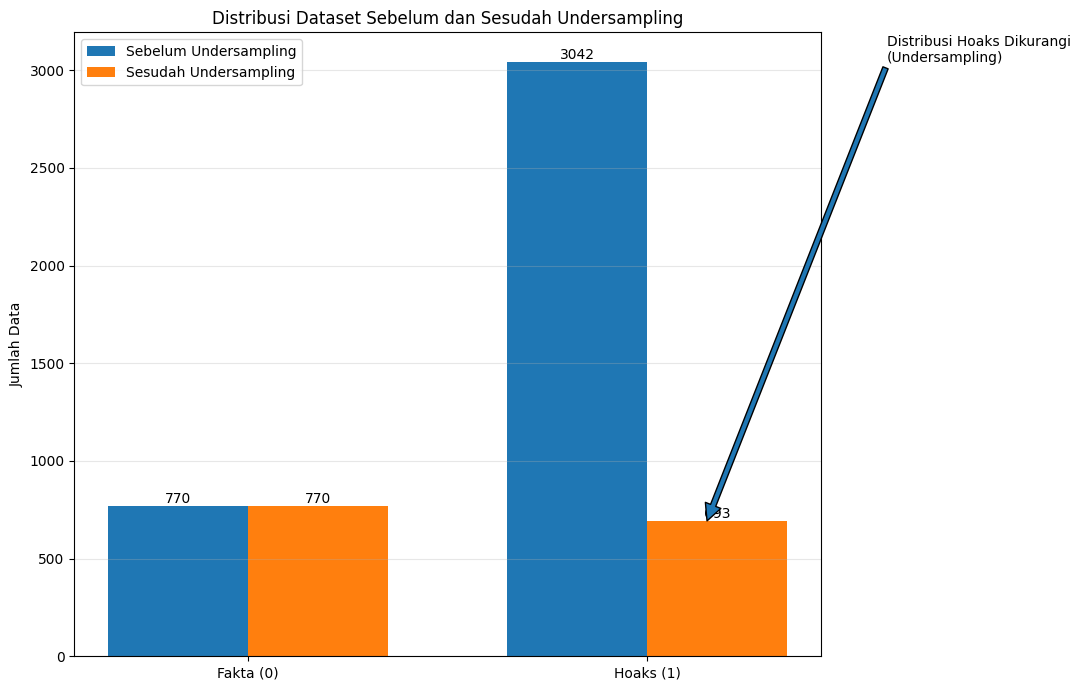

In [4]:
# Plot batang distribusi datset
# ============================================================
# 6. VISUALISASI DISTRIBUSI DATASET (VERSI LEBIH BAGUS)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Distribusi
before_counts = df['label'].value_counts().sort_index()
after_counts = df_balanced['label'].value_counts().sort_index()

labels = ['Fakta (0)', 'Hoaks (1)']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(11,7))

# Bar chart
bars1 = plt.bar(
    x - width/2,
    before_counts.values,
    width,
    label='Sebelum Undersampling'
)

bars2 = plt.bar(
    x + width/2,
    after_counts.values,
    width,
    label='Sesudah Undersampling'
)

# Angka di atas bar
for bar in bars1:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 15,
        f'{int(y)}',
        ha='center'
    )

for bar in bars2:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 15,
        f'{int(y)}',
        ha='center'
    )

# Tambahkan garis perubahan hoaks
plt.annotate(
    'Distribusi Hoaks Dikurangi\n(Undersampling)',
    xy=(1.15, after_counts.values[1]),
    xytext=(1.6, before_counts.values[1]),
    arrowprops=dict(),
    fontsize=10
)

plt.xticks(x, labels)

plt.ylabel('Jumlah Data')
plt.title('Distribusi Dataset Sebelum dan Sesudah Undersampling')

plt.legend()

# Grid biar enak dibaca
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### 2.2 Split Data (80% training, 20% testing)

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['tweet'],        # Fitur (teks)
    df['label'],        # Target (label hoaks / bukan)
    test_size=0.2,      # 20% data untuk testing
    random_state=42,    # Seed agar hasil split selalu sama (reproducible)
    stratify=df['label'] # Menjaga proporsi label tetap seimbang di train & test
)



In [6]:
# =========================
# SIMPAN HASIL SPLIT
# =========================

import pandas as pd

train_df = pd.DataFrame({
    "tweet": X_train_raw,
    "label": y_train
})

test_df = pd.DataFrame({
    "tweet": X_test_raw,
    "label": y_test
})

train_df.to_csv("data_train.csv", index=False)
test_df.to_csv("data_test.csv", index=False)

#### Mengambil data setelah splitting 

### 2.3 Proses Pembersihan teks 

In [34]:
X_train_clean = X_train_raw.apply(bersihkan_teks_total)
# Membersihkan data training menggunakan preprocessing lengkap
# apply() → menerapkan fungsi ke setiap baris data teks

# SELANJUTNYA MEMBERSIHKAN DATASET DENGAN 2 TIPE
X_test_clean = X_test_raw.apply(bersihkan_teks_total)  
# Data uji versi bersih (ideal condition)

X_test_noisy = X_test_raw.apply(bersihkan_teks_minimal)  
# Data uji versi noisy (real-world condition)
# Digunakan untuk menguji robustness model

### 2.4 Membuat dictionary dan menyimpan hasil preprocessing

In [35]:
data_mentah = {
    'X_train_clean': X_train_clean,  # Data training yang sudah dibersihkan
    'y_train': y_train,              # Label training

    'X_test_clean': X_test_clean,    # Data test bersih
    'y_test': y_test,                # Label test

    'X_test_noisy': X_test_noisy     # Data test kotor (simulasi dunia nyata)
}

# Menyimpan dictionary ke file .pkl menggunakan pickle
simpan_objek(data_mentah, '../data/processed/data_teks_bersih.pkl')

print("Data teks berhasil dibersihkan dan disimpan!")
# Notifikasi bahwa proses selesai

Data teks berhasil dibersihkan dan disimpan!
